# *Maternal Health Risk* dataset

[*UCI* webpage](https://archive.ics.uci.edu/dataset/863/maternal+health+risk)

First, we import the libraries that we will need to load, process and visualize the data.

Details about the different libraries and provided functions can be found in their respective documentation:
- `numpy` for numerical calculations https://numpy.org/doc/stable/
- `pandas` for data manipulation and analysis https://pandas.pydata.org/docs/
- `pyplot` from `matplotlib` for basic plotting functionalities https://matplotlib.org/stable/
- `seaborn` for data visualization https://seaborn.pydata.org/

The first line below is a Python 'magic command' to display the plots in the notebook.
The last three lines are to customize the style of figures, especially adding a light gray grid and increasing the default figure width.

In [1]:
%matplotlib inline
import numpy
import pandas
import matplotlib.pyplot as plt
import seaborn

seaborn.set_theme(style="white",
                  rc={"axes.grid": True, "grid.color": '#eaeaf2', "xtick.bottom": True, "ytick.left": True,
                     "figure.figsize": (10, 5)})

The [*Maternal Health Risk* dataset](https://archive.ics.uci.edu/dataset/863/maternal+health+risk) belongs to the area of health and medicine. It contains monitoring data of pregnant women collected mostly in a rural area of Bangladesh.
The classification task typically considered is to estimate the risk of maternal mortality.

The dataset contains six physiological attributes, namely the age (`Age`), upper and lower values of blood pressure (respectively `SystolicBP` and `DiastolicBP`), blood sugar concentration (`BS`), body temperature (`BodyTemp`) and heart rate (`HeartRate`), as well as a risk estimate (`RiskLevel`).

We load the data from the file and define variables for the original categorical target attribute, and for its numerical representation that we will use later on.

In [2]:
mhr_path = "./maternal+health+risk/Maternal Health Risk Data Set.csv"
mhr_dtf = pandas.read_csv(mhr_path, sep=",")
mhr_targetname = "RiskLevel"
mhr_numtargetname = "RiskNum"

We write a function to list the columns that have missing values in a given dataset, or report that there are none, and we apply it to the dataset we just loaded.

In [3]:
def check_missing_values(dtf):
    cols_missing_values = [c for c in dtf if dtf[c].isna().any()]
    if len(cols_missing_values) > 0:
        print("\n\t- ".join(
            ["The following %s columns contain missing values:" % len(cols_missing_values)]+
            cols_missing_values))
    else:
        print("No values are missing.")

check_missing_values(mhr_dtf)

No values are missing.


We show an outline of the dataset.

In [4]:
mhr_dtf

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk
...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk


All six physiological attributes take numerical values, while the risk level is represented using an ordinal attribute with three categories.

We create a new column encoding the risk level categories `low risk`, `mid risk` and `high risk` as numerical values `0`, `1` and `2`, respectively, so that the risk level are meaningfully ordered. We show their distribution as a histogram, using the Yellow-Orange-Brown (`YlOrBr`) color palette, such that the lower risk level is depicted in a lighter shade, yellow, whereas the higher risk level is depicted in a darker shade, brown.

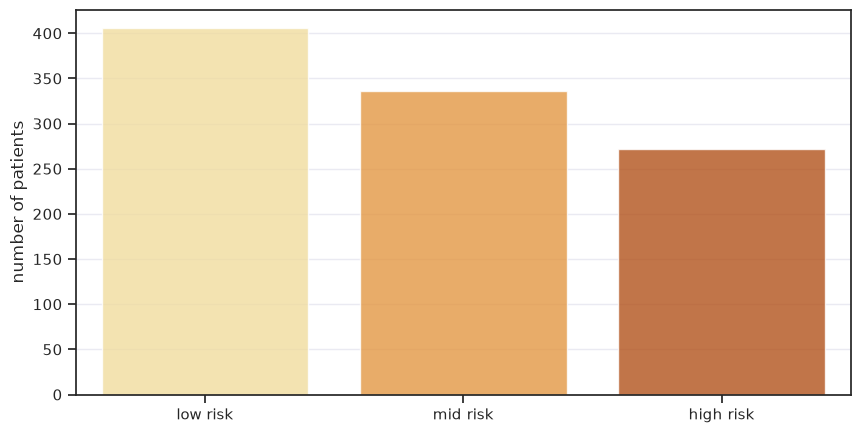

In [5]:
mhr_palette = seaborn.color_palette("YlOrBr", len(pandas.unique(mhr_dtf[mhr_targetname])))
mhr_dtf[mhr_numtargetname] = 0
mhr_dtf.loc[mhr_dtf[mhr_targetname]=="mid risk", mhr_numtargetname] = 1
mhr_dtf.loc[mhr_dtf[mhr_targetname]=="high risk", mhr_numtargetname] = 2

ax = seaborn.countplot(data=mhr_dtf, x=mhr_numtargetname, hue=mhr_numtargetname,
                 palette=mhr_palette, alpha=0.8, legend=None)
ax.set_xticks([0,1,2], ["low risk", "mid risk", "high risk"]);
ax.set_xlabel("");
ax.set_ylabel("number of patients");

We see that about forty percent of patients are evaluated as having a low health risk, whereas slightly more than a quarter are evaluated as having a high risk.

We show descriptive statistics, which by default include only numerical attributes.

The summary includes the number of distinct values (`count`, which is equal to the number of samples since no values are missing), the average value (`mean`), the standard deviation (`std`), the minimum and maximum values (`min` and `max`, respectively), as well as the 25th, 50th and 75th percentiles (`25%`, `50%` and `75%`, respectively).

In [6]:
mhr_dtf.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskNum
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775,0.867850
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702,0.807353
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000,0.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000,0.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000,1.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000,2.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000,2.000000


The minimum value, 25th, 50th and 75th percentiles are all equal for the body temperature (`BodyTemp`), only the maximum value differs, representing an abnormally elevated value in a few patients.

Next, we compute and display correlations between pairs of attributes, sorting the attributes by decreasing correlation with the risk level, represented as a numerical value between 1 and 3.

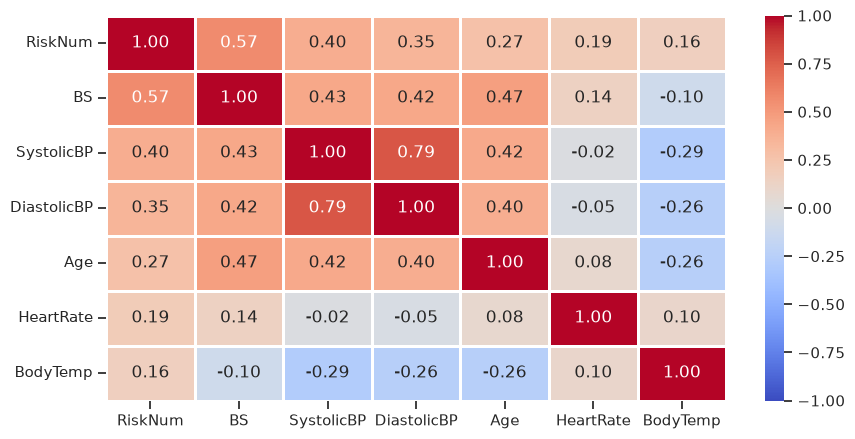

In [7]:
crm = mhr_dtf.corr(numeric_only=True)
sorted_columns = crm[mhr_numtargetname].sort_values(ascending=False).index
sorted_features = sorted_columns[1:]
seaborn.heatmap(crm.loc[sorted_columns,sorted_columns], linewidth=.8,
                vmin=-1, vmax=1, cmap="coolwarm",
                annot=True, fmt=".2f");

All physiological attributes are positively correlated with the numerical risk level. Since larger values of the numerical risk level indicate greater estimated health risk, this means that for all physiological attributes, higher values are associated with greater risk. This is more strongly the case for blood sugar concentration (`BS`), having a correlation of 0.57, whereas the correlation between risk level and heart rate and between risk level and body temperature are rather weak, both below twenty percent (0.19 and 0.16).

The two blood pressure attributes, `SystolicBP` and `DiastolicBP`, are quite strongly positively correlated (0.79). On the other hand, body temperature (`BodyTemp`) and age (`Age`) are negatively correlated, though not very strongly (-0.26), meaning that the few higher body temperatures have likely been recorded in younger patients.

We plot the distribution of each physiological attribute as a separate boxplot for each of the three risk groups.

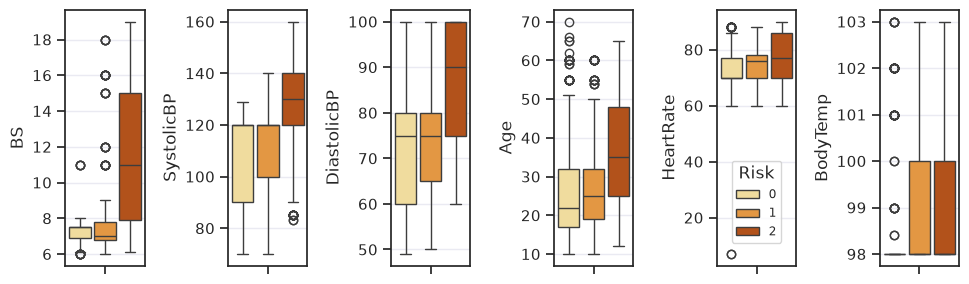

In [8]:
f, axes = plt.subplots(1, len(sorted_features))
for ci, c in enumerate(sorted_features):
    seaborn.boxplot(mhr_dtf, y=c, hue=mhr_numtargetname,
                    ax=axes[ci], width=0.95, dodge=True, gap=0.15,
                    palette=mhr_palette, legend=(ci==4))
    if ci==4:
        axes[ci].legend(title="Risk", fontsize="x-small", loc='center', bbox_to_anchor=(.5, .25))
f.set_figheight(3)
f.tight_layout()

The outlier value of seven beats per minutes observed as the heart rate for a patient in the low risk group is likely a measurement error.